# From proteins to precursors: a first tour of `alphapepttools` + `mulink`

This notebook is a gentle, end-to-end walkthrough for people who have **never used
either package**. We start from a raw DIA-NN report and finish with two volcano
plots: one at the **protein** level, and one at the **precursor** level in which we
highlight the precursors belonging to a single protein of interest.

**The two tools, in one sentence each**

| Package | What it does |
| --- | --- |
| [`alphapepttools`](https://github.com/MannLabs/alphapepttools) | Reads search-engine output into `AnnData` and gives you QC, preprocessing, statistics and plots that follow proteomics best practice. |
| [`mulink`](https://github.com/lucas-diedrich/mulink) | Remembers *how features at different levels relate to each other* (precursor → protein → gene) inside a `MuData` object, so you can move between levels without bookkeeping. |

**The dataset.** 20 samples from a Deep Visual Proteomics experiment, acquisition
approach `cnDVP`, measured on a timsTOF and searched with DIA-NN. Each sample is a
laser-excised region of a tissue section, taken from one of two compartments:

* `Cancer` — tumour regions (9 samples)
* `Immune` — immune-cell-rich regions (11 samples)

…across two donors (`sample_id` 991 and 992). Our biological question is deliberately
simple: **which proteins distinguish immune regions from tumour regions?**

**The plan**

1. Read one DIA-NN report at three feature levels
2. Attach the sample metadata
3. Preprocess (log → normalise → filter)
4. Check group separation with PCA
5. Protein-level differential expression → volcano
6. Link the levels with `mulink`
7. Ask *"which precursors make up this protein?"* → precursor-level volcano

## 0. Setup

In [1]:
from pathlib import Path

import matplotlib.patches as mpatches
import pandas as pd

import alphapepttools as at
import mulink  # noqa: F401  -- importing registers the `.link` namespace on MuData

# Run from either the repo root or the notebooks/ folder
DATA = Path("data") if Path("data").exists() else Path("../data")
REPORT = DATA / "report_cnDVP.parquet"
METADATA = DATA / "metadata_cnDVP.csv"

# Everything downstream keys off these three choices -- change them and re-run
CONDITION = "tissue"                     # column in the metadata to compare
COMPARISON = ("Cancer", "Immune")        # (group 1, group 2) for the t-test
PROTEIN_OF_INTEREST = "P08575"           # PTPRC / CD45, the pan-leukocyte marker

print(f"alphapepttools {at.__version__}  |  mulink {mulink.__version__}")

alphapepttools 0.4.0  |  mulink 0.0.3


/Users/jnimoca/Jose_BI/2_Infrastructure/PY46_MuLink_demo/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Read the DIA-NN report — three times

A DIA-NN `report.parquet` is a **long table**: one row per precursor per run. Most
analyses want a **matrix** instead (samples × features), and which matrix you want
depends on the question. `at.io.read_psm_table` builds that matrix and returns an
[`AnnData`](https://anndata.readthedocs.io) object:

* `adata.X` — the intensity matrix, **samples as rows, features as columns**
* `adata.obs` — one row of metadata per sample
* `adata.var` — one row of metadata per feature

We read the *same file* three times, at three **feature levels**. The `var_columns`
argument is the important bit: it carries the coarser level's identifier along into
`.var`, and that is exactly what `mulink` will later use to link the levels together.

> **Note for DIA-NN users:** `alphapepttools` also supports `level="peptides"`, but a
> DIA-NN report carries no peptide-level intensity column, so the usable hierarchy
> here is **precursors → proteins → genes**. "Precursor" means a peptide in a
> particular charge state and with particular modifications — one step finer than a
> peptide.

In [2]:
adata_precursors = at.io.read_psm_table(
    REPORT,
    search_engine="diann",
    level="precursors",
    var_columns=["proteins", "genes"],  # <- lets mulink link precursors up to proteins
)

adata_proteins = at.io.read_psm_table(
    REPORT,
    search_engine="diann",
    level="proteins",
    var_columns="genes",                # <- ...and proteins up to genes
)

adata_genes = at.io.read_psm_table(REPORT, search_engine="diann", level="genes")

for name, adata in [
    ("precursors", adata_precursors),
    ("proteins", adata_proteins),
    ("genes", adata_genes),
]:
    print(f"{name:11s} {adata.shape[0]:>3} samples x {adata.shape[1]:>6} features")

precursors   20 samples x  36068 features
proteins     20 samples x   5120 features
genes        20 samples x   5096 features


In [3]:
# .var remembers which protein and gene each precursor belongs to
adata_precursors.var.head()

,proteins,genes
precursor_id,,
(UniMod:1)AAAAAAAAAAGAAGGR2,Q86U42,PABPN1
(UniMod:1)AAAAAAGAASGLPGPVAQGLK2,Q96P70,IPO9
(UniMod:1)AAAAAAGAASGLPGPVAQGLK3,Q96P70,IPO9
(UniMod:1)AAAAAAGAGPEM(UniMod:35)VR2,P28482,MAPK1
(UniMod:1)AAAAAAGEAR2,P09417,QDPR


## 2. Attach the sample metadata

`at.pp.add_metadata` joins a `DataFrame` onto `.obs` (`axis=0`) or `.var` (`axis=1`).
It matches on the **index**, not on row order, so it cannot silently mislabel your
samples — but it does mean the index has to match.

Our metadata identifies samples by raw file name (`..._14821.d`), while DIA-NN's
`Run` column — which became `adata.obs_names` — has no `.d` suffix. One
`removesuffix` and they line up.

In [4]:
# sample_id is a donor label, not a quantity -- read it as text so it is never
# treated as a number in plots or tests
metadata = pd.read_csv(METADATA, dtype={"sample_id": str})
metadata.index = metadata["File Name"].str.removesuffix(".d")  # match DIA-NN's `Run`

adata_precursors = at.pp.add_metadata(adata_precursors, metadata, axis=0)
adata_proteins = at.pp.add_metadata(adata_proteins, metadata, axis=0)
adata_genes = at.pp.add_metadata(adata_genes, metadata, axis=0)

adata_proteins.obs[["sample_id", "tissue", "replicate_n", "Proteins.Identified"]].head()

,sample_id,tissue,replicate_n,Proteins.Identified
raw_name,,,,
Bluto_20251020_JoN_P37E24_991_Cancer_cnDVP_1_S3-A7_1_14821,991,Cancer,1,4213
Bluto_20251020_JoN_P37E35_991_Cancer_cnDVP_5_S3-B6_1_14823,991,Cancer,5,3744
Bluto_20251020_JoN_P37E45_991_Cancer_cnDVP_3_S3-C6_1_14825,991,Cancer,3,4049
Bluto_20251020_JoN_P37E56_991_Cancer_cnDVP_4_S3-D9_1_14827,991,Cancer,4,3819
Bluto_20251024_JoN_P37E01_992_Cancer_cnDVP_02_S6-H10_1_14849,992,Cancer,2,4880


In [5]:
# The design we are about to test: 2 compartments x 2 donors
adata_proteins.obs.groupby(["tissue", "sample_id"], observed=True).size()

tissue  sample_id
Cancer  991          4
        992          5
Immune  991          5
        992          6
dtype: int64

## 3. A first look at the data

`alphapepttools` plots all take a matplotlib `ax`, so you can mix them freely with
your own matplotlib or seaborn code. `at.pl.create_figure` returns a figure plus an
axis manager; call `.next()` to walk through the panels.

> **Worth knowing:** `axm[row, col]` also *rewinds* the `.next()` counter to that
> panel, so interleaving the two styles can quietly draw two plots into the same
> panel and leave the next one empty. The habit that avoids this entirely: grab the
> panels you need into named variables up front, then forget about `axm`.

/var/folders/x7/grkjlk8s223dy6234rnz1885mxz2_6/T/ipykernel_88589/928326513.py:25: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


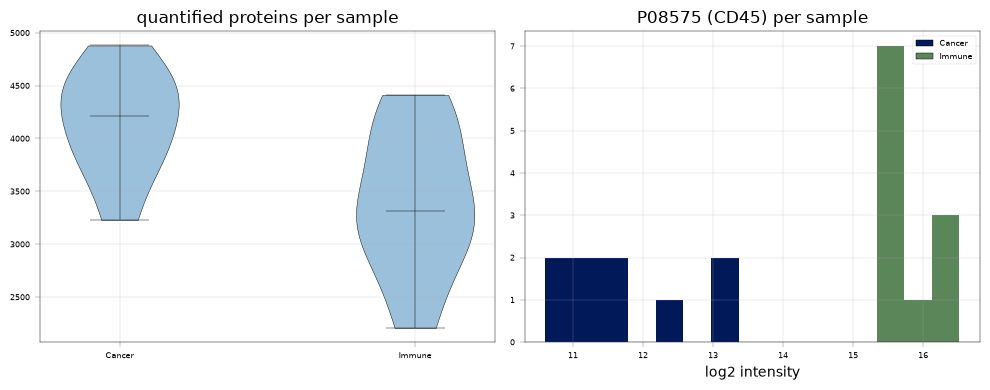

In [6]:
fig, axm = at.pl.create_figure(1, 2, figsize=(10, 4))
ax_depth, ax_marker = axm.next(), axm.next()

# How deep is each sample? (DIA-NN's own protein count, straight from .obs)
at.pl.violinplot(
    ax=ax_depth,
    data=adata_proteins,
    grouping_column="tissue",
    value_column="Proteins.Identified",
)
ax_depth.set_title("quantified proteins per sample")

# What does one protein look like across samples?
at.pl.histogram(
    ax=ax_marker,
    data=at.pp.nanlog(adata_proteins, base=2, copy=True, verbosity=0),
    value_column=PROTEIN_OF_INTEREST,
    color_map_column="tissue",
    bins=15,
    legend="auto",
)
ax_marker.set_xlabel("log2 intensity")
ax_marker.set_title(f"{PROTEIN_OF_INTEREST} (CD45) per sample")

fig.tight_layout()

Two things to take away. Tumour regions are quantified more deeply than immune
regions — a real difference in how much material each excised shape contained, and a
good reminder that we must normalise before comparing. And CD45, our protein of
interest, is already visibly bimodal between the two compartments.

## 4. Preprocess: log → normalise → filter

Three steps, in this order:

1. **`at.pp.nanlog`** — log2-transform. Proteomics intensities span orders of
   magnitude and are roughly log-normal; t-tests want something symmetric. "nan" in
   the name is the polite part: zeros become `NaN` ("not detected") instead of `-inf`.
2. **`at.pp.normalize`** — put samples on a common scale. `total_median` divides each
   sample by its median intensity, correcting the loading differences we just saw.
3. **`at.pp.filter_data_completeness`** — drop features too sparse to test. With
   `group_column="tissue"` and `keep_strategy="any"`, a protein is kept if it is
   well-measured in **at least one** group. That choice matters: a protein present in
   every immune region and absent from every tumour region is a *result*, not noise,
   and a naive global filter would throw it away.

Note the **layer checkpointing** pattern: each transformation is copied into
`adata.layers[...]` before the next one runs, so you can always go back and plot the
data as they were two steps ago without re-reading the report.

In [7]:
CHECKPOINTS = ["raw", "log2", "normalized"]


def preprocess(adata, max_missing_fraction=0.3):
    """log2 -> median-normalise -> drop sparse features, keeping every step in a layer."""
    adata = adata.copy()
    adata.layers["raw"] = adata.X.copy()

    at.pp.nanlog(adata, base=2, verbosity=0)
    adata.layers["log2"] = adata.X.copy()

    at.pp.normalize(adata, strategy="total_median")
    adata.layers["normalized"] = adata.X.copy()

    return at.pp.filter_data_completeness(
        adata,
        max_missing_fraction=max_missing_fraction,
        group_column=CONDITION,
        keep_strategy="any",   # keep a feature if it is complete in EITHER group
        action="drop",
    )


proteins = preprocess(adata_proteins)
precursors = preprocess(adata_precursors)

print(f"proteins   {adata_proteins.shape[1]:>6} -> {proteins.shape[1]:>6} features")
print(f"precursors {adata_precursors.shape[1]:>6} -> {precursors.shape[1]:>6} features")
print("checkpoints available:", [k for k in CHECKPOINTS if k in proteins.layers])

INFO:root:pp.filter_data_completeness(): drop 840 / 5120 features with >0.30 missing fraction.


INFO:root:pp.filter_data_completeness(): drop 15463 / 36068 features with >0.30 missing fraction.


proteins     5120 ->   4280 features
precursors  36068 ->  20605 features
checkpoints available: ['raw', 'log2', 'normalized']


## 5. Do the groups separate at all? (PCA)

Before testing thousands of proteins one at a time, check whether the effect you are
looking for is visible in the data as a whole. If PC1 already separates your groups,
differential expression will be easy. If instead PC1 separates *donors* or *batches*,
you have a confounder to deal with first.

PCA needs a complete matrix, so we fill the remaining gaps.
`at.pp.impute_gaussian` draws from a low, narrow Gaussian — the Perseus-style
"missing means low abundance" assumption. We impute into a **copy** used only for the
PCA; the statistics later run on the un-imputed data, where a missing value stays
missing.

`alphapepttools` stores the result in `.obsm["X_pca_obs"]` rather than scanpy's
`X_pca`: the `_obs` suffix makes it explicit that *samples* are the points.

Eyeballing a scatter plot is not enough to say *what* a component represents, so we
also ask `at.metrics.principal_component_regression` (PCR). It scores how much of a
given sample annotation is captured in PCA space — near 0 means the components ignore
it, near 1 means they track it closely.

INFO:alphapepttools.tl.embeddings:computing PCA


/Users/jnimoca/.local/share/uv/python/cpython-3.12-macos-aarch64-none/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/jnimoca/.local/share/uv/python/cpython-3.12-macos-aarch64-none/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/jnimoca/.local/share/uv/python/cpython-3.12-macos-aarch64-none/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/var/folders/x7/grkjlk8s223dy6234rnz1885mxz2_6/T/ipykernel_88589/1145826079.py:26: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
/Users/jnimoca/Jose_BI/2_Infrastructure/PY46_MuLink_demo/.venv/lib/python3.12/site-packages/alphapepttools/metrics/principal_component_regression.py:162: Pandas4Warning: is_categorical_dtype is deprecated and will be 

variance explained: ['PC1 65%', 'PC2 7%', 'PC3 7%']

how much of each annotation does PCA space capture? (PCR score)
  tissue                 0.26
  sample_id              0.06
  Proteins.Identified    0.59


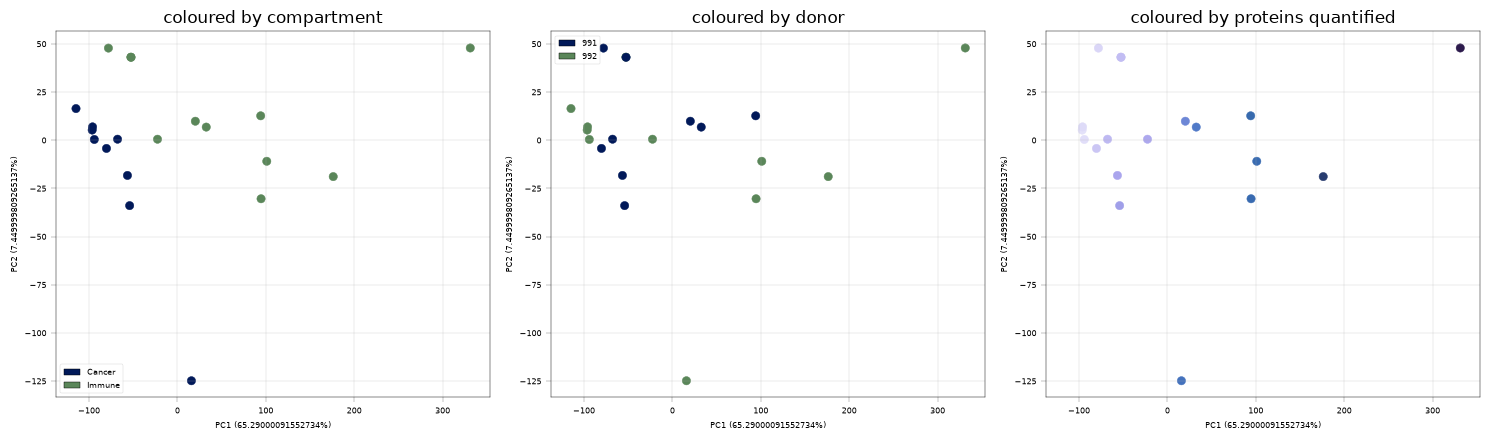

In [8]:
# PCR needs categorical covariates to be typed as such
for column in [CONDITION, "sample_id"]:
    proteins.obs[column] = proteins.obs[column].astype("category")

proteins_pca = at.pp.impute_gaussian(proteins, copy=True)
at.tl.pca(proteins_pca, n_comps=5)

fig, axm = at.pl.create_figure(1, 3, figsize=(15, 4.5))
ax_tissue, ax_donor, ax_depth = axm.next(), axm.next(), axm.next()

at.pl.plot_pca(data=proteins_pca, ax=ax_tissue, color_map_column=CONDITION, legend="auto")
ax_tissue.set_title("coloured by compartment")

at.pl.plot_pca(data=proteins_pca, ax=ax_donor, color_map_column="sample_id", legend="auto")
ax_donor.set_title("coloured by donor")

at.pl.plot_pca(
    data=proteins_pca,
    ax=ax_depth,
    color_map_column="Proteins.Identified",          # continuous -> sequential palette
    palette=at.pl.BaseColormaps.get("sequential"),
    legend="auto",
)
ax_depth.set_title("coloured by proteins quantified")

fig.tight_layout()

variance = proteins_pca.uns["variance_pca_obs"]["variance_ratio"]
print("variance explained:", [f"PC{i + 1} {v:.0%}" for i, v in enumerate(variance[:3])])
print()
print("how much of each annotation does PCA space capture? (PCR score)")
for covariate in [CONDITION, "sample_id", "Proteins.Identified"]:
    score = at.metrics.principal_component_regression(proteins_pca, covariate=covariate)
    print(f"  {covariate:22s} {score:.2f}")

Read the PCR scores rather than the scatter plot, and the picture is more interesting
than "the groups separate":

* **`Proteins.Identified` = 0.59** — PC1 carries 65% of the variance and what it mostly
  encodes is *how deeply each sample was quantified*. The third panel shows this
  directly: colour gets darker from left to right along PC1.
* **`tissue` = 0.26** — the compartment is a real but secondary axis. Cancer samples
  sit left of Immune samples on average, with genuine overlap.
* **`sample_id` = 0.06** — the donor is essentially irrelevant. Nothing to correct here.
  (Had this been the large number, `at.pp.scanpy_pycombat` is where you would go next.)

Two honest conclusions. First, there is **no batch effect worth correcting**, so we can
go straight to testing. Second, depth and compartment are **partly entangled** —
tumour regions yielded more material — so a global summary like PC1 is the wrong place
to look for the biology. A per-protein test is the right place, which is exactly what
we do next.

## 6. Protein-level differential expression

`at.tl.diff_exp_ttest` runs a Welch t-test per feature and returns a tidy
`DataFrame` — no reshaping needed. It already includes Benjamini-Hochberg corrected
p-values (`fdr`) and the `-log10(...)` columns the volcano plot expects.

`min_valid_values` is the guard rail: a feature must have at least that many
*measured* samples **in each group** to be tested at all. Features that fall short
come back with `NaN` statistics rather than a fabricated p-value — remember this,
because it comes back to bite us in step 10.

In [9]:
de_proteins = at.tl.diff_exp_ttest(
    proteins,
    between_column=CONDITION,
    comparison=COMPARISON,           # log2fc > 0 means higher in Cancer
    min_valid_values=3,
)

# Carry the gene symbols over from .var so the plot can be labelled with names
de_proteins["genes"] = proteins.var["genes"].reindex(de_proteins.index)

FDR_CUTOFF, FC_CUTOFF = 0.05, 1.0
de_proteins["status"] = "unchanged"
de_proteins.loc[
    (de_proteins["fdr"] < FDR_CUTOFF) & (de_proteins["log2fc"] > FC_CUTOFF), "status"
] = "up in Cancer"
de_proteins.loc[
    (de_proteins["fdr"] < FDR_CUTOFF) & (de_proteins["log2fc"] < -FC_CUTOFF), "status"
] = "up in Immune"

print(de_proteins["status"].value_counts().to_string())
de_proteins.nsmallest(10, "fdr")[["genes", "log2fc", "p_value", "fdr"]]

Comparing groups: Cancer vs Immune


status
unchanged       3214
up in Immune    1058
up in Cancer       8


,genes,log2fc,p_value,fdr
Q9HC16,APOBEC3G,-4.147553,4.881809e-07,0.001960
P00488,F13A1,-6.478974,3.197928e-06,0.002564
P13804,ETFA,-5.339064,3.439530e-06,0.002564
P48960,ADGRE5,-4.549985,3.833228e-06,0.002564
Q96F15,GIMAP5,-5.895598,3.040017e-06,0.002564
Q9NUV9,GIMAP4,-5.781299,3.658125e-06,0.002564
P38117,ETFB,-5.564013,4.498473e-06,0.002580
P08575,PTPRC,-5.945734,7.284059e-06,0.003655
Q06187,BTK,-5.139856,8.428512e-06,0.003759
P32942,ICAM3,-5.129528,1.054450e-05,0.004233


## 7. The protein volcano

`at.pl.volcano` works with **layers**: a list of `(column, value(s), colour_key)`
tuples. Each point is assigned to the *first* layer it matches, so the list acts as a
painting order — later entries end up in the background. Anything matching nothing
lands in a grey default layer.

`label_layers` says which of those layers get text labels, and `x_label_anchors`
stacks the labels tidily at fixed x-positions instead of letting them collide on top
of the points.

/var/folders/x7/grkjlk8s223dy6234rnz1885mxz2_6/T/ipykernel_88589/4183724279.py:29: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


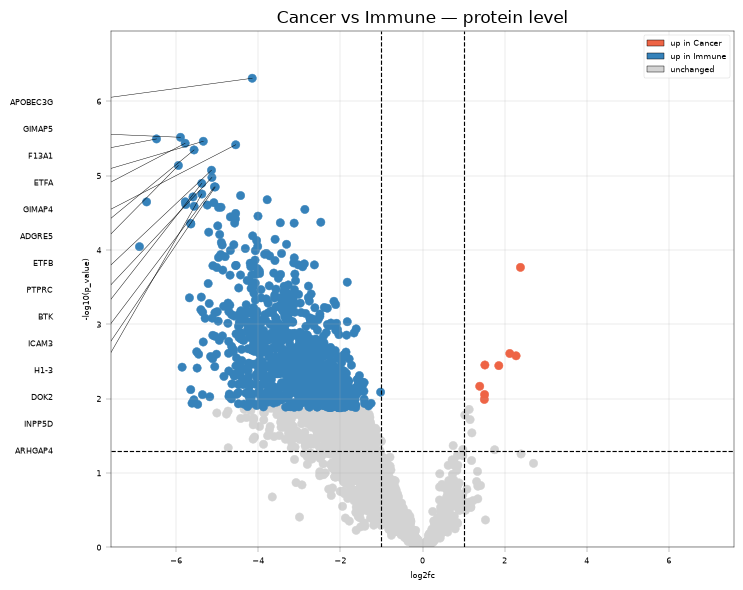

In [10]:
colors = {
    "up in Cancer": at.pl.BaseColors.get("orange"),
    "up in Immune": at.pl.BaseColors.get("blue"),
    "unchanged": at.pl.BaseColors.get("grey"),
}

fig, axm = at.pl.create_figure(1, 1, figsize=(7.5, 6))
ax = axm.next()

at.pl.volcano(
    data=de_proteins,
    x_column="log2fc",
    y_column="-log10(p_value)",
    ax=ax,
    layers=[
        ("status", "up in Cancer", "up in Cancer"),
        ("status", "up in Immune", "up in Immune"),
        ("status", "unchanged", "unchanged"),
    ],
    color_dict=colors,
    label_layers=["up in Cancer", "up in Immune"],
    display_id_column="genes",        # label with gene symbols, not UniProt IDs
    max_labels=14,
    x_label_anchors=[-9, 9],
    x_thresholds=(-FC_CUTOFF, FC_CUTOFF),
    legend="auto",
)
ax.set_title(f"{COMPARISON[0]} vs {COMPARISON[1]} — protein level")
fig.tight_layout()

The result is lopsided — over a thousand proteins up in the immune regions against a
handful up in the tumour regions — which is what you expect when one compartment is
packed with a cell type the other lacks.

The labelled hits read like a textbook: **PTPRC** (CD45), **BTK**, **DOK2**,
**ICAM3**, **GIMAP4/5**, **APOBEC3G**, **F13A1** — canonical leukocyte proteins. The
laser captured what we asked it to capture, which is the best sanity check a spatial
proteomics experiment can give you.

So far, so ordinary. Now the part that needs `mulink`.

## 8. Linking the levels with `mulink`

A protein-level hit is an **aggregate**. DIA-NN measured a set of precursors and
summarised them into one number per protein, and sometimes that summary hides
trouble: one very noisy precursor, or a protein whose precursors disagree because a
peptide is shared with another protein. To check, you need to get from a protein back
to *its* precursors.

You could do that with a `groupby` on `.var["proteins"]`. `mulink` does something
more general: it stores the whole precursor → protein → gene hierarchy as a
**directed acyclic graph** in `mdata.varp["feature_mapping"]` and gives you graph
queries over it. `at.io.mulink_from_anndatas` builds that object from the AnnData
objects we already have, reconstructing the edges from the `var_columns` we asked for
back in step 1.

In [11]:
mdata = at.io.mulink_from_anndatas(
    {
        "precursors": adata_precursors,
        "proteins": adata_proteins,
        "genes": adata_genes,
    }
)

mdata

  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:00<00:00, 12.34it/s]

100%|██████████| 2/2 [00:00<00:00, 12.31it/s]

MuData object with n_obs × n_vars = 20 × 46284
  varp:	'feature_mapping'
  3 modalities
    precursors:	20 × 36068
      obs:	'File Name', 'sample_id', 'tissue', 'approach', 'replicate_n', 'evowell', 'lcms_id', 'Precursors.Identified', 'Proteins.Identified'
      var:	'proteins', 'genes'
      layers:	None
    proteins:	20 × 5120
      obs:	'File Name', 'sample_id', 'tissue', 'approach', 'replicate_n', 'evowell', 'lcms_id', 'Precursors.Identified', 'Proteins.Identified'
      var:	'genes'
      layers:	None
    genes:	20 × 5096
      obs:	'File Name', 'sample_id', 'tissue', 'approach', 'replicate_n', 'evowell', 'lcms_id', 'Precursors.Identified', 'Proteins.Identified'
      layers:	None

In [12]:
print("modalities:      ", list(mdata.mod))
print("total features:  ", mdata.shape[1])
print("linkage matrix:  ", mdata.varp["feature_mapping"].shape,
      f"({mdata.varp['feature_mapping'].nnz:,} edges)")

modalities:       ['precursors', 'proteins', 'genes']
total features:   46284
linkage matrix:   (46284, 46284) (77,256 edges)


### Which way do the arrows point?

Edges run **fine → coarse**: `precursor → protein → gene`. Two consequences worth
remembering, because the vocabulary trips everyone up at first:

| Query | Walks | Example |
| --- | --- | --- |
| `mdata.link.query.ancestors(x)` | *against* the arrows, i.e. **down** to finer levels | gene → its proteins and precursors |
| `mdata.link.query.descendants(x)` | *along* the arrows, i.e. **up** to coarser levels | precursor → its protein and gene |

Both return a **new `MuData`** subset to the matched features, with `.obs`, `.var` and
`.X` intact — so the result is still an ordinary object you can hand straight back to
`alphapepttools`.

By default the graph is a **transitive closure**, so a precursor links directly to its
gene as well as to its protein; you never have to hop level by level.

In [13]:
# The full hierarchy underneath one gene -- small enough to draw
gene_of_interest = adata_proteins.var.loc[PROTEIN_OF_INTEREST, "genes"]
subgraph = mdata.link.query.ancestors(gene_of_interest)

print(f"everything linked to {gene_of_interest}:")
for name, mod in subgraph.mod.items():
    print(f"  {name:11s} {mod.shape[1]:>3} features")

everything linked to PTPRC:
  precursors   16 features
  proteins      1 features
  genes         1 features


/var/folders/x7/grkjlk8s223dy6234rnz1885mxz2_6/T/ipykernel_88589/1355281267.py:30: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


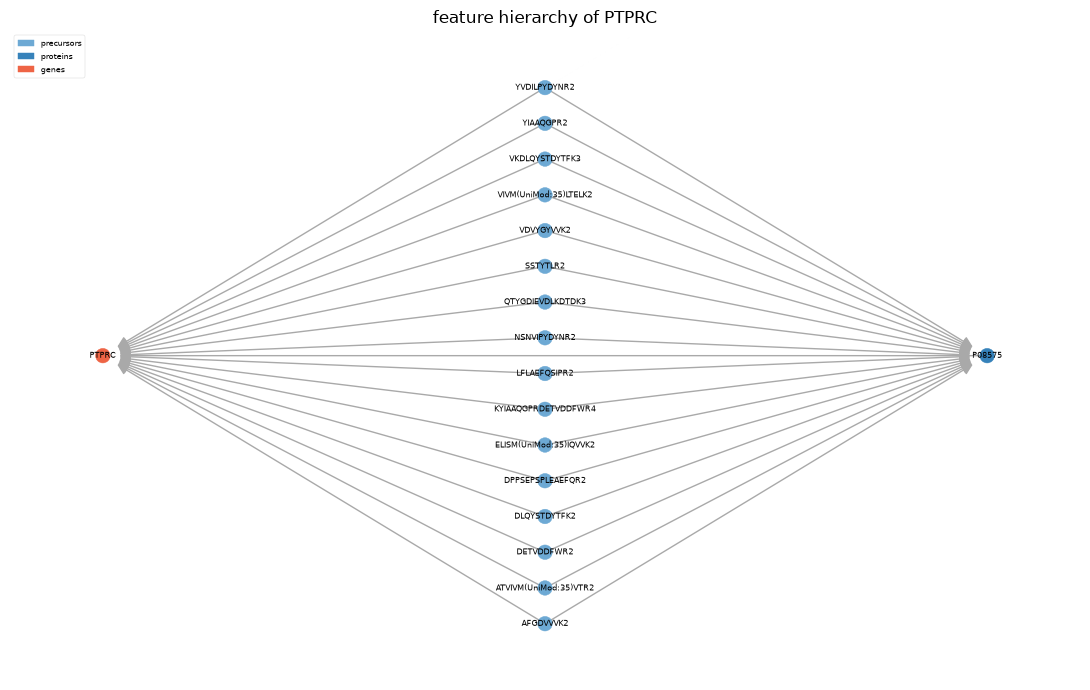

In [14]:
# Colour each node by the level it lives on. Node order follows subgraph.var_names.
level_colors = {
    "precursors": at.pl.BaseColors.get("lightblue"),
    "proteins": at.pl.BaseColors.get("blue"),
    "genes": at.pl.BaseColors.get("orange"),
}
level_of = {name: level for level, mod in subgraph.mod.items() for name in mod.var_names}
node_colors = [level_colors[level_of[name]] for name in subgraph.var_names]

fig, axm = at.pl.create_figure(1, 1, figsize=(11, 7))
ax = axm.next()

subgraph.link.pl.graph(
    ax=ax,
    node_color=node_colors,
    node_size=110,
    with_labels=True,
    font_size=6,
    arrows=True,
    arrowsize=16,
    edge_color="darkgrey",
    min_target_margin=12,   # keep arrowheads clear of the node markers
)
at.pl.add_legend_to_axes_from_patches(
    ax,
    [mpatches.Patch(color=c, label=level) for level, c in level_colors.items()],
    loc="upper left",
)
ax.set_title(f"feature hierarchy of {gene_of_interest}")
fig.tight_layout()

One gene, one protein group, and the precursors quantified for it. Each column is one
level — check the legend for which is which — and every arrowhead points from the
specific to the general: precursor → protein, protein → gene.

Notice that each precursor has an edge reaching the *gene* directly, not only its
protein. That is the **transitive closure** at work, and it is the shortcut that lets
you ask "which precursors support this gene?" in one hop instead of walking the
hierarchy level by level.

> `link.pl.graph()` lays the graph out with networkx, which is slow for large subsets,
> and the column order comes from networkx rather than from your modality order. Query
> first, plot second.

## 9. From one protein to its precursors

Now the query we actually came for. `include_mods="precursors"` restricts the result
to the precursor modality, giving us exactly the feature set we want to highlight.

In [15]:
poi_precursors = (
    mdata.link.query.ancestors(PROTEIN_OF_INTEREST, include_mods="precursors")
    .mod["precursors"]
    .var_names
)

# Not every precursor survives the completeness filter from step 4
tested = [p for p in poi_precursors if p in precursors.var_names]

print(f"{gene_of_interest} ({PROTEIN_OF_INTEREST})")
print(f"  precursors in the report:   {len(poi_precursors)}")
print(f"  precursors after filtering: {len(tested)}")
print("  examples:", list(poi_precursors[:4]))

PTPRC (P08575)
  precursors in the report:   16
  precursors after filtering: 13
  examples: ['AFGDVVVK2', 'ATVIVM(UniMod:35)VTR2', 'DETVDDFWR2', 'DLQYSTDYTFK2']


## 10. The precursor volcano, with one protein highlighted

Same test, same plotting function — just run on the 20,000-precursor matrix instead of
the 4,000-protein one, with our protein's precursors promoted to their own layer.
Because layers are matched in order and the highlight layer comes first, those points
are drawn on top of everything else.

In [16]:
de_precursors = at.tl.diff_exp_ttest(
    precursors,
    between_column=CONDITION,
    comparison=COMPARISON,
    min_valid_values=3,
)

# Mark the precursors that mulink told us belong to our protein
poi_label = f"{gene_of_interest} precursors"
de_precursors["highlight"] = "other precursors"
de_precursors.loc[de_precursors.index.isin(tested), "highlight"] = poi_label

print(de_precursors["highlight"].value_counts().to_string())

Comparing groups: Cancer vs Immune


highlight
other precursors    20592
PTPRC precursors       13


/var/folders/x7/grkjlk8s223dy6234rnz1885mxz2_6/T/ipykernel_88589/2070643111.py:27: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


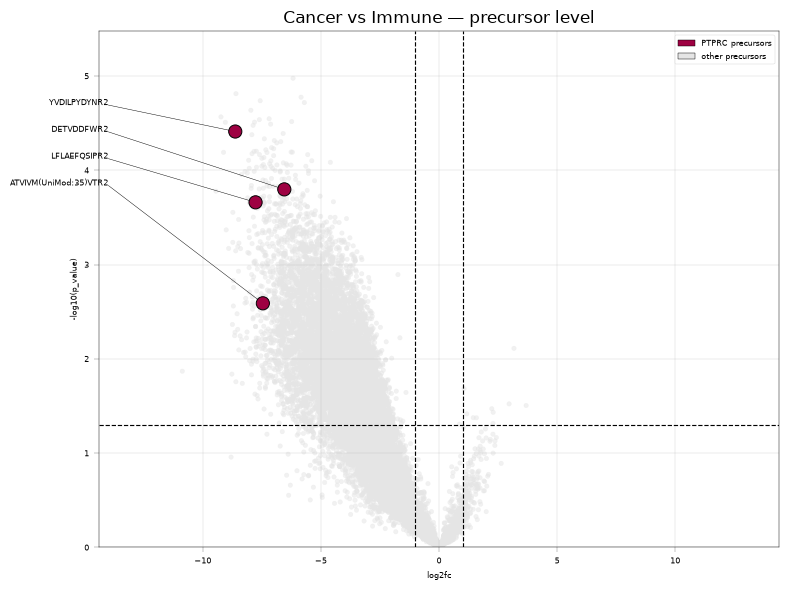

In [17]:
fig, axm = at.pl.create_figure(1, 1, figsize=(8, 6))
ax = axm.next()

at.pl.volcano(
    data=de_precursors,
    x_column="log2fc",
    y_column="-log10(p_value)",
    ax=ax,
    layers=[
        # 4th element of the tuple = extra plotting kwargs for this layer only
        ("highlight", poi_label, poi_label,
         {"scatter_kwargs": {"s": 90, "edgecolor": "black", "linewidth": 0.7, "zorder": 5}}),
        ("highlight", "other precursors", "other precursors",
         {"scatter_kwargs": {"s": 10, "alpha": 0.5}}),
    ],
    color_dict={
        poi_label: at.pl.BaseColors.get("red"),
        "other precursors": at.pl.BaseColors.get("grey", lighten=0.4),
    },
    label_layers=[poi_label],
    max_labels=8,
    x_label_anchors=[-14],
    x_thresholds=(-FC_CUTOFF, FC_CUTOFF),
    legend="auto",
)
ax.set_title(f"{COMPARISON[0]} vs {COMPARISON[1]} — precursor level")
fig.tight_layout()

### Where did the other precursors go?

Count the red points — there are only four, far fewer than the precursors `mulink`
handed us. The accounting goes: **16** precursors linked to CD45 in the report, **13**
surviving the completeness filter, **8** with a fold change, and only **4** with a
p-value. Two guard rails are responsible:

* a fold change needs at least one measurement in *each* group, so the 5 precursors
  never seen in a tumour region have no `log2fc` at all;
* `min_valid_values=3` needs three *measured* samples in each group for a t-test, and
  anything short of that returns `NaN` — which a volcano plot cannot place.

For a protein this strongly restricted to one compartment, that is not a flaw in the
data; it *is* the finding. The table below shows the detection counts behind each
precursor: most of CD45's precursors were seen in 0–2 of the 9 tumour regions and in
all 11 immune regions. **The strongest evidence here is the least testable**, which is
a trade-off worth understanding before you tune these thresholds.

In [18]:
poi_intensities = precursors[:, tested].to_df().join(precursors.obs[CONDITION])
detection = poi_intensities.groupby(CONDITION, observed=True).count().T
detection.columns = [f"detected in {c} (n={(precursors.obs[CONDITION] == c).sum()})"
                     for c in detection.columns]
detection = detection.join(de_precursors[["log2fc", "p_value", "fdr"]])
detection.sort_values("fdr")

,detected in Cancer (n=9),detected in Immune (n=11),log2fc,p_value,fdr
YVDILPYDYNR2,8,11,-8.627298,0.000039,0.031308
DETVDDFWR2,3,11,-6.551474,0.000160,0.031983
LFLAEFQSIPR2,9,11,-7.768414,0.000219,0.031983
ATVIVM(UniMod:35)VTR2,3,11,-7.459934,0.002578,0.035147
AFGDVVVK2,2,11,-6.496546,NaN,NaN
DLQYSTDYTFK2,1,10,-3.756781,NaN,NaN
ELISM(UniMod:35)IQVVK2,2,10,-4.316807,NaN,NaN
NSNVIPYDYNR2,2,11,-6.138536,NaN,NaN
QTYGDIEVDLKDTDK3,0,11,NaN,NaN,NaN
SSTYTLR2,0,8,NaN,NaN,NaN


In [19]:
poi_stats = de_precursors.loc[de_precursors["highlight"] == poi_label]
testable = poi_stats.dropna(subset=["p_value"])
protein_log2fc = de_proteins.loc[PROTEIN_OF_INTEREST, "log2fc"]

print(f"protein-level log2fc:                    {protein_log2fc:>6.2f}")
print(f"precursors linked / kept / testable:     "
      f"{len(poi_precursors)} / {len(tested)} / {len(testable)}")
print(f"testable precursor log2fc, median:       {testable['log2fc'].median():>6.2f}")
print(f"testable precursor log2fc, range:        "
      f"{testable['log2fc'].min():.2f} to {testable['log2fc'].max():.2f}")
print(f"agreeing in sign with the protein:       "
      f"{int((testable['log2fc'] < 0).sum())} / {len(testable)}")
print(f"significant on their own (fdr < 0.05):   "
      f"{int((testable['fdr'] < 0.05).sum())} / {len(testable)}")

protein-level log2fc:                     -5.95
precursors linked / kept / testable:     16 / 13 / 4
testable precursor log2fc, median:        -7.61
testable precursor log2fc, range:        -8.63 to -6.55
agreeing in sign with the protein:       4 / 4
significant on their own (fdr < 0.05):   4 / 4


### Was the protein-level number trustworthy?

Yes. All four testable precursors move in the same direction as the protein-level
estimate, each is significant on its own, and the median precursor fold change sits
close to the protein's. The untestable ones point the same way for the strongest
possible reason: they were not detected in tumour regions at all.

A protein whose precursors scattered across both sides of the volcano would be the
warning sign — a shared peptide, a mis-assigned precursor, an interference — and worth
looking at before putting it in a figure.

The two panels below make the same point from the raw numbers: the protein is a clean
on/off difference between compartments, and its precursors are shifted as a coherent
group relative to the 20,000 others.

/var/folders/x7/grkjlk8s223dy6234rnz1885mxz2_6/T/ipykernel_88589/1634370728.py:26: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


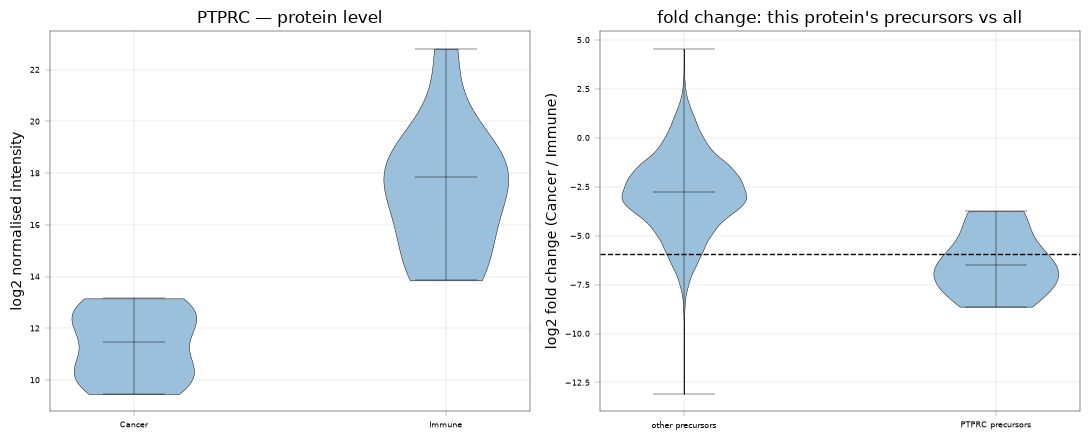

In [20]:
fig, axm = at.pl.create_figure(1, 2, figsize=(11, 4.5))
ax_protein, ax_fc = axm.next(), axm.next()

# (a) the protein itself, per compartment
at.pl.violinplot(
    ax=ax_protein,
    data=proteins,
    grouping_column=CONDITION,
    value_column=PROTEIN_OF_INTEREST,
)
ax_protein.set_ylabel("log2 normalised intensity")
ax_protein.set_title(f"{gene_of_interest} — protein level")

# (b) its precursors' fold changes against the global distribution
fold_changes = de_precursors[["log2fc", "highlight"]].dropna(subset=["log2fc"])
at.pl.violinplot(
    ax=ax_fc,
    data=fold_changes,
    grouping_column="highlight",
    value_column="log2fc",
)
ax_fc.axhline(protein_log2fc, color="black", linestyle="--", linewidth=1)
ax_fc.set_ylabel("log2 fold change (Cancer / Immune)")
ax_fc.set_title("fold change: this protein's precursors vs all")

fig.tight_layout()

## Recap

What we did, and which tool did it:

| Step | Call |
| --- | --- |
| One report → three matrices | `at.io.read_psm_table(..., level=..., var_columns=...)` |
| Metadata onto samples | `at.pp.add_metadata(..., axis=0)` |
| log → normalise → filter | `at.pp.nanlog`, `at.pp.normalize`, `at.pp.filter_data_completeness` |
| Is the effect there at all? | `at.pp.impute_gaussian`, `at.tl.pca`, `at.pl.plot_pca` |
| Which proteins change? | `at.tl.diff_exp_ttest`, `at.pl.volcano` |
| Remember how the levels relate | `at.io.mulink_from_anndatas` |
| Protein → its precursors | `mdata.link.query.ancestors(..., include_mods="precursors")` |

The `mulink` step is what made the last question cheap. Once the hierarchy lives in
the object, *"show me the evidence behind this hit"* is a one-line query instead of a
merge you have to get right by hand — and it stays correct as you subset, filter and
pass the object around.

### Things to try next

* Change `PROTEIN_OF_INTEREST` to `"P13796"` (LCP1, more precursors) or `"P00488"`
  (F13A1) and re-run from step 9.
* Swap the comparison to the two donors — `CONDITION = "sample_id"`,
  `COMPARISON = ("991", "992")` — to see how little separates them relative to the
  compartments.
* Use `descendants()` in the other direction: start from a *precursor* and ask which
  protein and gene it supports.
* Loosen `min_valid_values` to `2`, or raise `max_missing_fraction`, and watch how
  many of CD45's precursors become testable.
* For small groups, try the moderated test `at.tl.diff_exp_ebayes` and compare hit
  lists.
* Every function's docstring carries best-practice notes and runnable examples —
  `help(at.tl.diff_exp_ttest)` is genuinely worth reading.